# **<center><font style="color:rgb(100,109,254)">Real-Time 3D Pose Detection & Pose Classification with Mediapipe and Python</font> </center>**

Pose Detection (also known as Pose Estimation) is a widely used computer vision task that enables you to predict humans poses in images or videos by localizing the key body joints (also reffered  as landmarks), these are elbows, shoulders, and knees, etc. 

<img src='https://drive.google.com/uc?export=download&id=1hT-lhDvzft8vVQv6ObSok73h7A4l5CXf'>


[MediaPipe](https://google.github.io/mediapipe/solutions/pose.html) provides a robust solution capable of predicting **thirty-three 3D landmarks** on a human body in real-time with high accuracy even on CPU. It utilizes a two-step machine learning pipeline, by using a detector it first localizes the person within the frame and then uses the pose landmarks detector to predict the  landmarks within the region of interest.


<img src='https://drive.google.com/uc?export=download&id=1c1vFXlRbN9r4ONKIE3sEmaLsWEfm2vpF'>


For the videos, the detector is used only for the very first frame and then the ROI is derived from the previous frame’s pose landmarks using a tracking method. Also when the tracker loses track of the identify body pose presence in a frame, the detector is invoked again for the next frame which reduces the computation and latency. The image below shows the thirty-three pose landmarks along with their indexes.

<img src="https://drive.google.com/uc?export=download&id=1CDO0KiXZEOuWc7xLEm7EFLLQf2hydCoI">

### **<font style="color:rgb(134,19,348)"> Import the Libraries</font>**

Let's start by importing the required libraries.

In [1]:
!pip3 install mediapipe

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import math
import cv2
import numpy as np
from time import time
import mediapipe as mp
import matplotlib.pyplot as plt

2024-04-11 21:59:19.479597: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-11 21:59:19.522226: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-11 21:59:19.797882: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-11 21:59:19.799631: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-11 21:59:21.010873: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

## **<font style="color:rgb(134,19,348)">Initialize the Pose Detection Model</font>**

The first thing that we need to do is initialize the pose class using the **`mp.solutions.pose`** syntax and then we will call the setup function **`mp.solutions.pose.Pose()`** with the arguments:

* **`static_image_mode`** - It is a boolean value that is if set to `False`, the detector is only invoked as needed, that is in the very first frame or when the tracker loses track. If set to `True`, the person detector is invoked on every input image. So you should probably set this value to True when working with a bunch of unrelated images not videos. Its default value is `False`.

* **`min_detection_confidence`** - It is the minimum detection confidence with range `(0.0 , 1.0)` required to consider the person-detection model's prediction correct. Its default value is `0.5`. This means if the detector has a prediction confidence of greater or equal to 50% then it will be considered as a positive detection.


* **`min_tracking_confidence`** - It is the minimum tracking confidence `([0.0, 1.0])` required to consider the landmark-tracking model's tracked pose landmarks valid. If the confidence is less than the set value then the detector is invoked again in the next frame/image, so increasing its value increases the robustness, but also increases the latency. Its default value is `0.5`.


* **`model_complexity`** - It is the complexity of the pose landmark model. As there are three different models to choose from so the possible values are `0`, `1`, or `2`. The higher the value, the more accurate the results are, but at the expense of higher latency. Its default value is `1`.


* **`smooth_landmarks`** - It is a boolean value that is if set to `True`, pose landmarks across different frames are filtered to reduce noise. But only works when **`static_image_mode`** is also set to `False`. Its default value is `True`.

Then we will also initialize **`mp.solutions.drawing_utils`** class that will allow us to visualize the landmarks after detection, instead of using this, you can also use OpenCV to visualize the landmarks.

In [3]:
# Initializing mediapipe pose class.
mp_pose = mp.solutions.pose

# Setting up the Pose function.
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.3, model_complexity=2)

# Initializing mediapipe drawing class, useful for annotation.
mp_drawing = mp.solutions.drawing_utils 

I0000 00:00:1712852963.402699  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712852963.432104  266640 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2


### **<font style="color:rgb(134,19,348)">Read an Image</font>**

Now we will read a sample image using the function [**`cv2.imread()`**](https://docs.opencv.org/3.4/d4/da8/group__imgcodecs.html#ga288b8b3da0892bd651fce07b3bbd3a56) and then display that image using the [**`matplotlib`**](https://matplotlib.org/stable/index.html) library. 

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


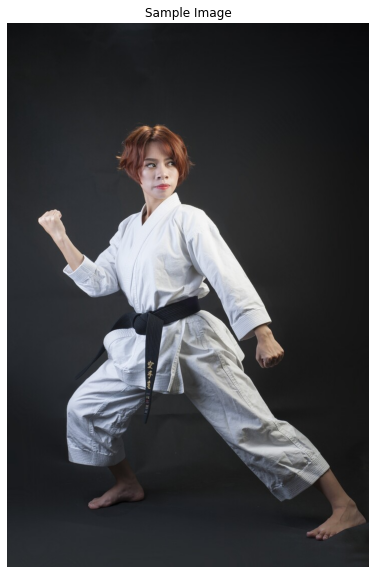

In [ ]:
# Read an image from the specified path.
sample_img = cv2.imread('media/sample.jpg')

# Specify a size of the figure.
plt.figure(figsize = [
    
    10, 10])

# Display the sample image, also convert BGR to RGB for display. 
plt.title("Sample Image");plt.axis('off');plt.imshow(sample_img[:,:,::-1]);plt.show()

## **<font style="color:rgb(134,19,348)">Perform Pose Detection</font>**

Now we will pass the image to the pose detection machine learning pipeline by using the function **`mp.solutions.pose.Pose().process()`**. But the pipeline expects the input images in **`RGB`** color format so first we will have to convert the sample image from **`BGR`** to **`RGB`** format using the function [**`cv2.cvtColor()`**](https://docs.opencv.org/3.4/d8/d01/group__imgproc__color__conversions.html#ga397ae87e1288a81d2363b61574eb8cab) as OpenCV reads images in **`BGR`** format (instead of **`RGB`**).

After performing the pose detection, we will get a list of thirty-three landmarks representing the body joint locations of the prominent person in the image. Each landmark has:

* **`x`** - It is the landmark x-coordinate normalized to [0.0, 1.0] by the image width.


* **`y`**: It is the landmark y-coordinate normalized to [0.0, 1.0] by the image height.


* **`z`**: It is the landmark z-coordinate normalized to roughly the same scale as **`x`**. It represents the landmark depth with midpoint of hips being the origin, so the smaller the value of z, the closer the landmark is to the camera. 

* **`visibility`**: It is a value with range [0.0, 1.0] representing the possibility of the landmark being visible (not occluded) in the image. This is a useful variable when deciding if you want to show a particular joint because it might be occluded or partially visible in the image.

After performing the pose detection on the sample image above, we will display the first two landmarks from the list, so that you get a better idea of the output of the model.

In [5]:
# Perform pose detection after converting the image into RGB format.
results = pose.process(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))

# Check if any landmarks are found.
if results.pose_landmarks:
    
    # Iterate two times as we only want to display first two landmarks.
    for i in range(2):
        
        # Display the found normalized landmarks.
        print(f'{mp_pose.PoseLandmark(i).name}:\n{results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value]}') 

NOSE:
x: 0.42638200521469116
y: 0.2825169861316681
z: -0.5677525997161865
visibility: 1.0

LEFT_EYE_INNER:
x: 0.4352526068687439
y: 0.26287171244621277
z: -0.5314675569534302
visibility: 0.9999998807907104



Now we will convert the two normalized landmarks displayed above into their original scale by using the width and height of the  image.

In [6]:
# Retrieve the height and width of the sample image.
image_height, image_width, _ = sample_img.shape

# Check if any landmarks are found.
if results.pose_landmarks:
    
    # Iterate two times as we only want to display first two landmark.
    for i in range(2):
        
        # Display the found landmarks after converting them into their original scale.
        print(f'{mp_pose.PoseLandmark(i).name}:') 
        print(f'x: {results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value].x * image_width}')
        print(f'y: {results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value].y * image_height}')
        print(f'z: {results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value].z * image_width}')
        print(f'visibility: {results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value].visibility}\n')

NOSE:
x: 306.56866174936295
y: 305.11834502220154
z: -408.2141191959381
visibility: 1.0

LEFT_EYE_INNER:
x: 312.94662433862686
y: 283.9014494419098
z: -382.1251734495163
visibility: 0.9999998807907104






Now we will draw the detected landmarks on the sample image using the function **`mp.solutions.drawing_utils.draw_landmarks()`** and display the resultant image using the [**`matplotlib`**](https://matplotlib.org/stable/index.html) library. 

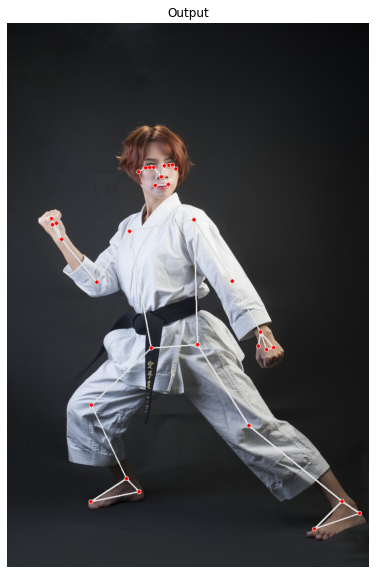

In [7]:
# Create a copy of the sample image to draw landmarks on.
img_copy = sample_img.copy()

# Check if any landmarks are found.
if results.pose_landmarks:
    
    # Draw Pose landmarks on the sample image.
    mp_drawing.draw_landmarks(image=img_copy, landmark_list=results.pose_landmarks, connections=mp_pose.POSE_CONNECTIONS)
       
    # Specify a size of the figure.# hips obtuse : Crunch
            # elif left_hip_angle > 100 and left_hip_angle < 160 or right_hip_angle > 100 and right_hip_angle < 160:
            #     label = "Crunches
    fig = plt.figure(figsize = [10, 10])

    # Display the output image with the landmarks drawn, also convert BGR to RGB for display. 
    plt.title("Output");plt.axis('off');plt.imshow(img_copy[:,:,::-1]);plt.show()

Now we will go a step further and visualize the landmarks in three-dimensions (3D) using the function **`mp.solutions.drawing_utils.plot_landmarks()`**. We will need the POSE_WORLD_LANDMARKS that is another list of pose landmarks in world coordinates that has the 3D coordinates in meters with the origin at the center between the hips of the person. 

<img src='https://drive.google.com/uc?export=download&id=1JPQCLOPZkS8b3VBNtmc2aOfuAjhddSMZ' width=400>

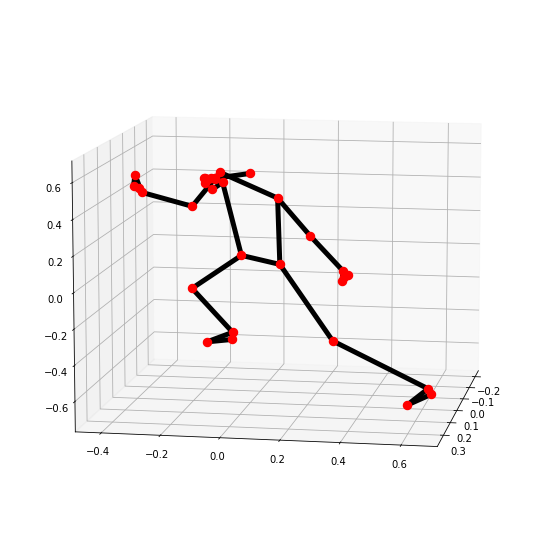

In [8]:
# Plot Pose landmarks in 3D.
mp_drawing.plot_landmarks(results.pose_world_landmarks, mp_pose.POSE_CONNECTIONS)

**Note:** This is actually a neat hack by mediapipe, the coordinates returned are not actually in **3D** but by setting hip landmark as the origin allows us to measure relative distance of the other points from the hip, and since this distance increases or decreases depending upon if you're close or further from the camera it gives us a sense of depth of each landmark point. 

### **<font style="color:rgb(134,19,348)">Create a Pose Detection Function</font>**

Now we will put all this together to create a function that will perform pose detection on an image and will visualize the results or return the results depending upon the passed arguments.

In [9]:
def detectPose(image, pose, display=True):
    '''
    This function performs pose detection on an image.
    Args:
        image: The input image with a prominent person whose pose landmarks needs to be detected.
        pose: The pose setup function required to perform the pose detection.
        display: A boolean value that is if set to true the function displays the original input image, the resultant image, 
                 and the pose landmarks in 3D plot and returns nothing.
    Returns:
        output_image: The input image with the detected pose landmarks drawn.
        landmarks: A list of detected landmarks converted into their original scale.
    '''
    
    # Create a copy of the input image.
    output_image = image.copy()
    
    # Convert the image from BGR into RGB format.
    imageRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Perform the Pose Detection.
    results = pose.process(imageRGB)
    
    # Retrieve the height and width of the input image.
    height, width, _ = image.shape
    
    # Initialize a list to store the detected landmarks.
    landmarks = []
    
    # Check if any landmarks are detected.
    if results.pose_landmarks:
    
        # Draw Pose landmarks on the output image.
        mp_drawing.draw_landmarks(image=output_image, landmark_list=results.pose_landmarks,
                                  connections=mp_pose.POSE_CONNECTIONS)
        
        # Iterate over the detected landmarks.
        for landmark in results.pose_landmarks.landmark:
            
            # Append the landmark into the list.
            landmarks.append((int(landmark.x * width), int(landmark.y * height),
                                  (landmark.z * width)))
    
    # Check if the original input image and the resultant image are specified to be displayed.
    if display:
    
        # Display the original input image and the resultant image.
        plt.figure(figsize=[22,22])
        plt.subplot(121);plt.imshow(image[:,:,::-1]);plt.title("Original Image");plt.axis('off');
        plt.subplot(122);plt.imshow(output_image[:,:,::-1]);plt.title("Output Image");plt.axis('off');
        
        # Also Plot the Pose landmarks in 3D.
        mp_drawing.plot_landmarks(results.pose_world_landmarks, mp_pose.POSE_CONNECTIONS)
        
    # Otherwise
    else:
        
        # Return the output image and the found landmarks.
        return output_image, landmarks

Now we will utilize the function created above to perform pose detection on a few sample images and display the results.

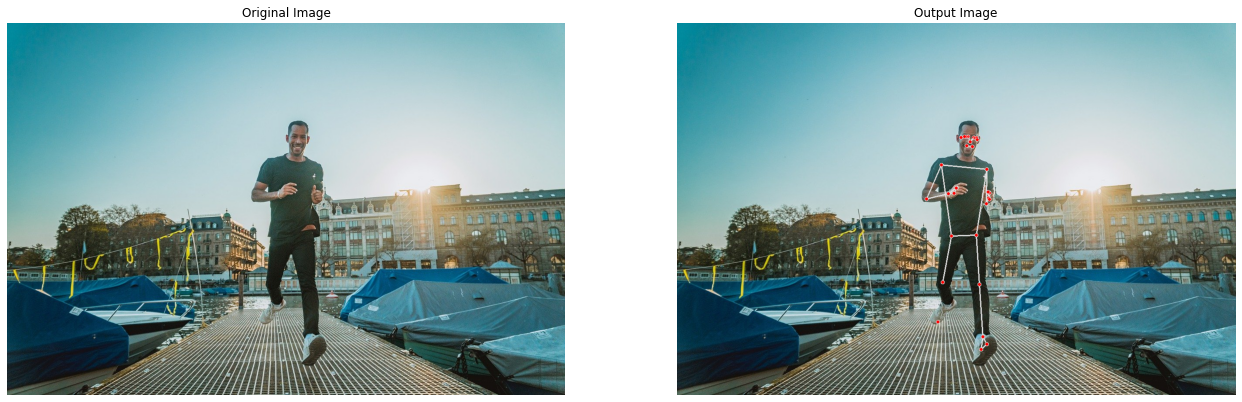

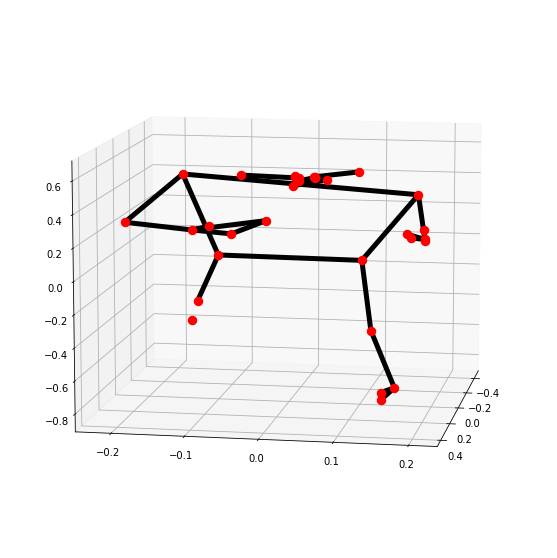

In [10]:
# Read another sample image and perform pose detection on it.
image = cv2.imread('media/sample1.jpg')
detectPose(image, pose, display=True)

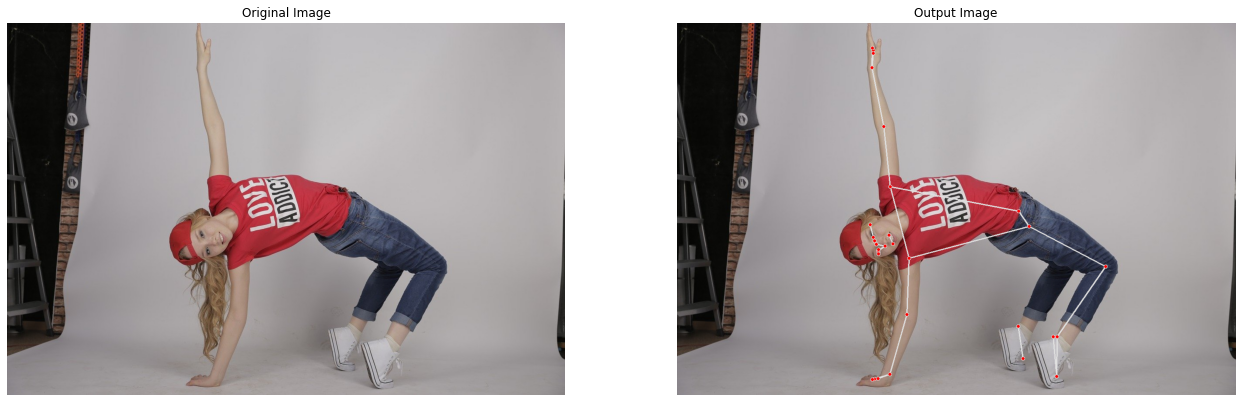

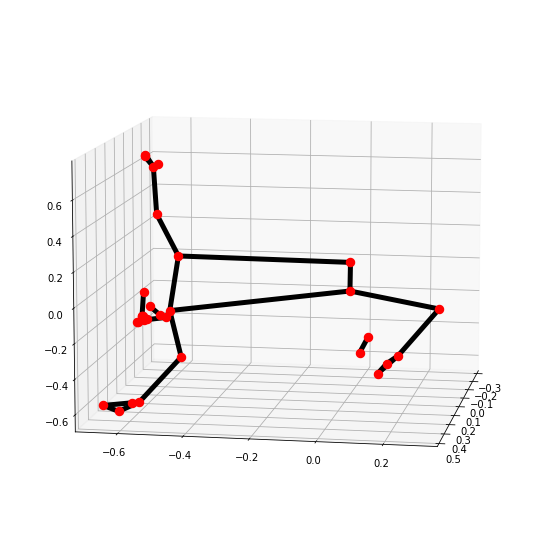

In [11]:
# Read another sample image and perform pose detection on it.
image = cv2.imread('media/sample2.jpg')
detectPose(image, pose, display=True)

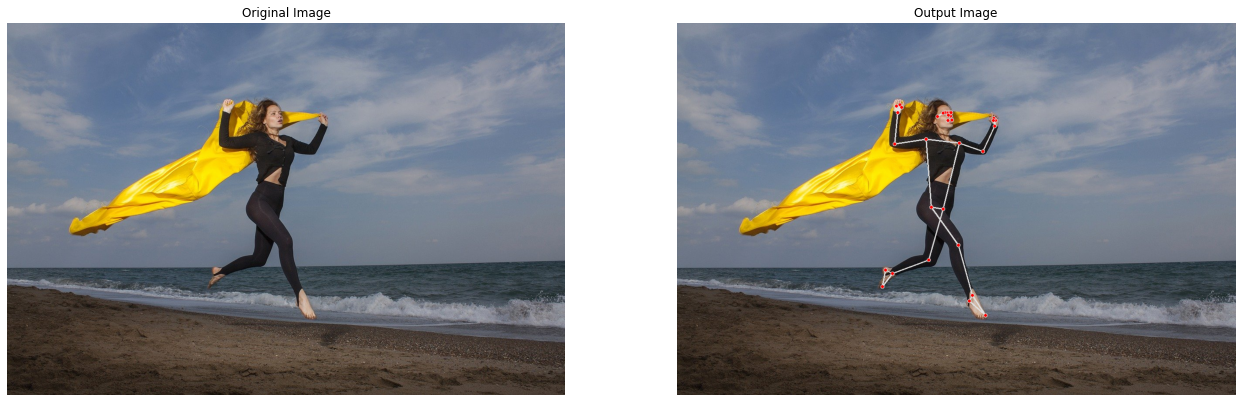

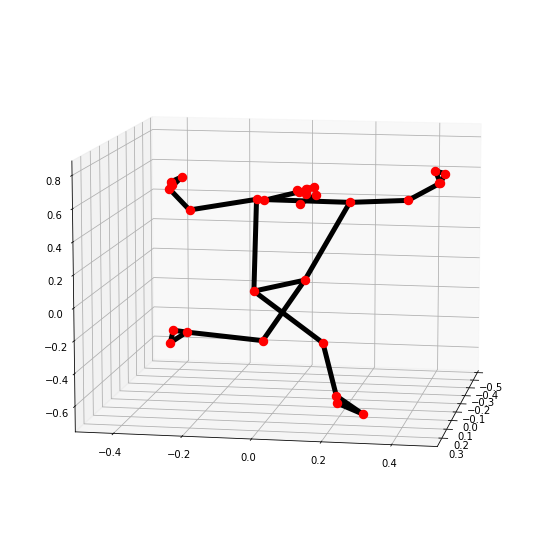

In [12]:
# Read another sample image and perform pose detection on it.
image = cv2.imread('media/sample3.jpg')
detectPose(image, pose, display=True)

### **<font style="color:rgb(134,19,348)">Pose Detection On Real-Time Webcam Feed/Video</font>**

The results on the images were pretty good, now we will try the function on a real-time webcam feed and a video. Depending upon whether you want to run pose detection on a video stored in the disk or on the webcam feed, you can comment and uncomment the initialization code of the VideoCapture object accordingly.

In [13]:
# Setup Pose function for video.
pose_video = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, model_complexity=1)

# Initialize the VideoCapture object to read from the webcam.
video = cv2.VideoCapture(1)

# Create named window for resizing purposes
cv2.namedWindow('Pose Detection', cv2.WINDOW_NORMAL)


# Initialize the VideoCapture object to read from a video stored in the disk.
#video = cv2.VideoCapture('media/running.mp4')

# Set video camera size
video.set(3,1280)
video.set(4,960)

# Initialize a variable to store the time of the previous frame.
time1 = 0

# Iterate until the video is accessed successfully.
while video.isOpened():
    
    # Read a frame.
    ok, frame = video.read()
    
    # Check if frame is not read properly.
    if not ok:
        
        # Break the loop.
        break
    
    # Flip the frame horizontally for natural (selfie-view) visualization.
    frame = cv2.flip(frame, 1)
    
    # Get the width and height of the frame
    frame_height, frame_width, _ =  frame.shape
    
    # Resize the frame while keeping the aspect ratio.
    frame = cv2.resize(frame, (int(frame_width * (640 / frame_height)), 640))
    
    # Perform Pose landmark detection.
    frame, _ = detectPose(frame, pose_video, display=False)
    
    # Set the time for this frame to the current time.
    time2 = time()
    
    # Check if the difference between the previous and this frame time > 0 to avoid division by zero.
    if (time2 - time1) > 0:
    
        # Calculate the number of frames per second.
        frames_per_second = 1.0 / (time2 - time1)
        
        # Write the calculated number of frames per second on the frame. 
        cv2.putText(frame, 'FPS: {}'.format(int(frames_per_second)), (10, 30),cv2.FONT_HERSHEY_PLAIN, 2, (0, 255, 0), 3)
    
    # Update the previous frame time to this frame time.
    # As this frame will become previous frame in next iteration.
    time1 = time2
    
    # Display the frame.
    cv2.imshow('Pose Detection', frame)
    
    # Wait until a key is pressed.
    # Retreive the ASCII code of the key pressed
    k = cv2.waitKey(1) & 0xFF
    
    # Check if 'ESC' is pressed.
    if(k == 27):
        
        # Break the loop.
        break

# Release the VideoCapture object.
video.release()

# Close the windows.
cv2.destroyAllWindows()

I0000 00:00:1712852968.669893  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712852968.690702  266728 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2
[ WARN:0@10.734] global /io/opencv/modules/videoio/src/cap_v4l.cpp (902) open VIDEOIO(V4L2:/dev/video1): can't open camera by index



Cool! so it works great on the videos too. The model is pretty fast and accurate.

## **<font style="color:rgb(134,19,348)">Pose Classification with Angle Heuristics</font>**

We have learned to perform pose detection, now we will level up our game by also classifying different yoga poses using the calculated angles of various joints. We will first detect the pose landmarks and then use them to compute angles between joints and depending upon those angles we will recognize the yoga pose of the prominent person in an image.

<img src='https://drive.google.com/uc?export=download&id=1lhAcgq2jy5NavGQeYjTwwEAZIu6Aeypg' width=500>

But this approach does have a drawback that limits its use to a controlled environment, the calculated angles vary with the angle between the person and the camera. So the person needs to be facing the camera straight to get the best results.

### **<font style="color:rgb(134,19,348)">Create a Function to Calculate Angle between Landmarks</font>**

Now we will create a function that will be capable of calculating angles between three landmarks. The angle between landmarks? Do not get confused, as this is the same as calculating the angle between two lines. 

The first point (landmark) is considered as the starting point of the first line, the second point (landmark) is considered as the ending point of the first line and the starting point of the second line as well, and the third point (landmark) is considered as the ending point of the second line.

<img src='https://drive.google.com/uc?export=download&id=1KSN2OnenNMZ7Jwai_E1jeWdP5Mzay3Ad' width=400>

In [14]:
def calculateAngle(landmark1, landmark2, landmark3):
    '''
    This function calculates angle between three different landmarks.
    Args:
        landmark1: The first landmark containing the x,y and z coordinates.
        landmark2: The second landmark containing the x,y and z coordinates.
        landmark3: The third landmark containing the x,y and z coordinates.
    Returns:
        angle: The calculated angle between the three landmarks.

    '''

    # Get the required landmarks coordinates.
    x1, y1, _ = landmark1
    x2, y2, _ = landmark2
    x3, y3, _ = landmark3

    # Calculate the angle between the three points
    angle = math.degrees(math.atan2(y3 - y2, x3 - x2) - math.atan2(y1 - y2, x1 - x2))
    
    # Check if the angle is less than zero.
    if angle < 0:

        # Add 360 to the found angle.
        angle += 360
    
    # Return the calculated angle.
    return angle

Now we will test the function created above to calculate angle three landmarks with dummy values.

In [15]:
# Calculate the angle between the three landmarks.
angle = calculateAngle((558, 326, 0), (642, 333, 0), (718, 321, 0))

# Display the calculated angle.
print(f'The calculated angle is {angle}')

The calculated angle is 166.26373169437744


### **<font style="color:rgb(134,19,348)">Create a Function to Perform Pose Classification</font>**

Now we will create a function that will be capable of classifying different yoga poses using the calculated angles of various joints. The function will be capable of identifying the following yoga poses:

* **Warrior II Pose**
* **T Pose**
* **Tree Pose**

In [16]:
# def classifyPose(landmarks, output_image, display=False):

#     '''
#     This function classifies yoga poses depending upon the angles of various body joints.
#     Args:
#         landmarks: A list of detected landmarks of the person whose pose needs to be classified.
#         output_image: A image of the person with the detected pose landmarks drawn.
#         display: A boolean value that is if set to true the function displays the resultant image with the pose label 
#         written on it and returns nothing.
#     Returns:
#         output_image: The image with the detected pose landmarks drawn and pose label written.
#         label: The classified pose label of the person in the output_image.

#     '''
    
#     # Initialize the label of the pose. It is not known at this stage.
#     label = 'Unknown Pose'

#     # Specify the color (Red) with which the label will be written on the image.
#     color = (0, 0, 255)


    
#     # Calculate the required angles.
#     #----------------------------------------------------------------------------------------------------------------
    
#     # Get the angle between the left shoulder, elbow and wrist points. 
#     left_elbow_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
#                                       landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value],
#                                       landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value])
    
#     # Get the angle between the right shoulder, elbow and wrist points. 
#     right_elbow_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
#                                        landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value],
#                                        landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value])   
    
#     # Get the angle between the left elbow, shoulder and hip points. 
#     left_shoulder_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value],
#                                          landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
#                                          landmarks[mp_pose.PoseLandmark.LEFT_HIP.value])

#     # Get the angle between the right hip, shoulder and elbow points. 
#     right_shoulder_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
#                                           landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
#                                           landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value])

#     # Get the angle between the left hip, knee and ankle points. 
#     left_knee_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
#                                      landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value],
#                                      landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value])

#     # Get the angle between the right hip, knee and ankle points 
#     right_knee_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
#                                       landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value],
#                                       landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value])
    
    
#     left_hip_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
#                                       landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
#                                       landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value])
    
#     right_hip_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
#                                         landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
#                                         landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value])
    
#     left_waist_leg_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
#                                         landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
#                                         landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value])

#     right_waist_leg_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
#                                         landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
#                                         landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value])
#     # Get the angle between left knee, heel and foot
#     left_foot_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value],
#                                       landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value],
#                                       landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value])
    
#     # Get the angle between right knee, heel and foot
#     right_foot_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value],
#                                       landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value],
#                                       landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value])

#     left_ankle_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value],
#                                       landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value],
#                                       landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value])
    
#     right_ankle_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value],
#                                       landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value],
#                                       landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value])
    
#     # print(f'Left Elbow Angle: {left_elbow_angle}')
#     # print(f'Right Elbow Angle: {right_elbow_angle}')
#     # print(f'Left Shoulder Angle: {left_shoulder_angle}')
#     # print(f'Right Shoulder Angle: {right_shoulder_angle}')
#     # print(f'Left Knee Angle: {left_knee_angle}')
#     # print(f'Right Knee Angle: {right_knee_angle}')
#     # print(f'Left Hip Angle: {left_hip_angle}')
#     # print(f'Right Hip Angle: {right_hip_angle}')
#     # print(f'Left Waist Leg Angle: {left_waist_leg_angle}')
#     # print(f'Right Waist Leg Angle: {right_waist_leg_angle}')
#     # print(f'Left Foot Angle: {left_foot_angle}')
#     # print(f'Right Foot Angle: {right_foot_angle}')

#     ## if any angle greater than 180, subtract from 360

#     if left_elbow_angle > 180:
#         left_elbow_angle = 360 - left_elbow_angle
    
#     if right_elbow_angle > 180:
#         right_elbow_angle = 360 - right_elbow_angle
    
#     if left_shoulder_angle > 180:
#         left_shoulder_angle = 360 - left_shoulder_angle
    
#     if right_shoulder_angle > 180:
#         right_shoulder_angle = 360 - right_shoulder_angle
    
#     if left_knee_angle > 180:
#         left_knee_angle = 360 - left_knee_angle
        
#     if right_knee_angle > 180:
#         right_knee_angle = 360 - right_knee_angle
    
#     if left_hip_angle > 180:
#         left_hip_angle = 360 - left_hip_angle
    
#     if right_hip_angle > 180:
#         right_hip_angle = 360 - right_hip_angle

#     if left_waist_leg_angle > 180:
#         left_waist_leg_angle = 360 - left_waist_leg_angle

#     if right_waist_leg_angle > 180:
#         right_waist_leg_angle = 360 - right_waist_leg_angle

#     if left_foot_angle > 180:
#         left_foot_angle = 360 - left_foot_angle
    
#     if right_foot_angle > 180:
#         right_foot_angle = 360 - right_foot_angle
    
#     print()
#     print("after 180")
#     print()
    
#     print(f'Left Elbow Angle: {left_elbow_angle}')
#     print(f'Right Elbow Angle: {right_elbow_angle}')
#     print(f'Left Shoulder Angle: {left_shoulder_angle}')
#     print(f'Right Shoulder Angle: {right_shoulder_angle}')
#     print(f'Left Knee Angle: {left_knee_angle}')
#     print(f'Right Knee Angle: {right_knee_angle}')
#     print(f'Left Hip Angle: {left_hip_angle}')
#     print(f'Right Hip Angle: {right_hip_angle}')
#     # print(f'Left Waist Leg Angle: {left_waist_leg_angle}')
#     # print(f'Right Waist Leg Angle: {right_waist_leg_angle}')
#     # print(f'Left Foot Angle: {left_foot_angle}')
#     # print(f'Right Foot Angle: {right_foot_angle}')

    
#     #--------------------------------------------------------------------------------------------------------------

#     # Check if the both arms are straight.
#     if left_elbow_angle > 165 and left_elbow_angle < 195 and right_elbow_angle > 165 and right_elbow_angle < 195:
        
        
#     # Check if it is the squat pose.
#     #----------------------------------------------------------------------------------------------------------------
#         if left_shoulder_angle > 90 and left_shoulder_angle < 130 and right_shoulder_angle > 90 and right_shoulder_angle < 130:

#             if left_hip_angle > 60 and left_hip_angle < 100 and right_hip_angle > 60 and right_hip_angle < 100:
                
#                 label = 'Squat'
                
#         # Check V-sit: 
#         #----------------------------------------------------------------------------------------------------------------

#         # Required Hip angle
#         if left_hip_angle > 60 and left_hip_angle < 110 and right_hip_angle > 60 and right_hip_angle < 110:

#             # Both legs straight:
#             if left_knee_angle > 165 and left_knee_angle < 195 or right_knee_angle > 165 and right_knee_angle < 195:

#                 label = 'V Sit'

#         # Check if it is the warrior II pose.
#         #----------------------------------------------------------------------------------------------------------------
            
#         # Check if shoulders are at the required angle.
#         if left_shoulder_angle > 80 and left_shoulder_angle < 110 and right_shoulder_angle > 80 and right_shoulder_angle < 110:

#             # Check if one leg is straight.
#             if left_knee_angle > 165 and left_knee_angle < 195 or right_knee_angle > 165 and right_knee_angle < 195:

#                 # Check if the other leg is bended at the required angle.
#                 if left_knee_angle > 90 and left_knee_angle < 120 or right_knee_angle > 90 and right_knee_angle < 120:

#                     # Specify the label of the pose that is Warrior II pose.
#                     label = 'Warrior II Pose' 
                        
#     # ----------------------------------------------------------------------------------------------------------------
    
#     # T pose.
#     #----------------------------------------------------------------------------------------------------------------
    
#         # Check if both legs are straight
#         if left_knee_angle > 160 and left_knee_angle < 195 and right_knee_angle > 160 and right_knee_angle < 195:

#             # check if shoulders raised sideways
#             if left_shoulder_angle > 80 and left_shoulder_angle < 140 and right_shoulder_angle > 80 and right_shoulder_angle < 140:

#                 # check if hips straight:
#                 if left_hip_angle > 160 and left_hip_angle < 195 and right_hip_angle > 160 and right_hip_angle < 195:

#                     label = 'T Pose'

#     #----------------------------------------------------------------------------------------------------------------
    
#     # Tree pose.
#     #----------------------------------------------------------------------------------------------------------------
    
#     # # Check if one leg is straight
#     # if left_knee_angle > 165 and left_knee_angle < 195 or right_knee_angle > 165 and right_knee_angle < 195:

#     #     # Check if the other leg is bended at the required angle.
#     #     if left_knee_angle > 315 and left_knee_angle < 335 or right_knee_angle > 25 and right_knee_angle < 45:

#     #         # Specify the label of the pose that is tree pose.
#     #         label = 'Tree Pose'

#     if (left_knee_angle > 165 and left_knee_angle < 195 and right_knee_angle > 25 and right_knee_angle < 45) or (right_knee_angle > 165 and right_knee_angle < 195 and left_knee_angle > 25 and left_knee_angle < 45):
#          label = 'Tree Pose'
    
#     #----------------------------------------------------------------------------------------------------------------

#     # Bridge Pose
#     #----------------------------------------------------------------------------------------------------------------
    
#     # Check angle between hip, knee and ankle

#     if left_knee_angle > 70 and left_knee_angle < 80 or right_knee_angle > 70 and right_knee_angle < 80:

#         if(left_shoulder_angle > 30 and left_shoulder_angle < 40 or right_shoulder_angle > 30 and right_shoulder_angle < 40):

#             label = 'Bridge Pose'

#     #----------------------------------------------------------------------------------------------------------------

#     # Lunges
#     #----------------------------------------------------------------------------------------------------------------
    
#     # Check angle between hip, knee and ankle

#     if(left_hip_angle > 90 and left_hip_angle < 110 or right_hip_angle > 90 and right_hip_angle < 110):

#         if(left_knee_angle > 80 and left_knee_angle < 100 and right_knee_angle > 100 and right_knee_angle < 130  or  right_knee_angle > 80 and right_knee_angle < 100 and left_knee_angle > 100 and left_knee_angle < 130):
#                 label = "Lunges"

#     #----------------------------------------------------------------------------------------------------------------

#     # Crunches
#     #----------------------------------------------------------------------------------------------------------------
    
#     if left_hip_angle > 100 and left_hip_angle < 160 or right_hip_angle > 100 and right_hip_angle < 160:

#         if left_knee_angle  > 50 and left_knee_angle < 90 or right_knee_angle > 50 and  right_knee_angle < 90:

#             label = "Crunches"
                
#     #----------------------------------------------------------------------------------------------------------------

#     # Plow pose
#     #----------------------------------------------------------------------------------------------------------------

#     # legs straight
    
#     if left_knee_angle > 160 and left_knee_angle < 195 or right_knee_angle > 160 and right_knee_angle < 195:

#         # arms straight 

#         if left_elbow_angle > 165 and left_elbow_angle < 195 or right_elbow_angle > 165 and right_elbow_angle < 195:

#             # shoulders at around 90 degree to arms:

#             if left_shoulder_angle > 80 and left_shoulder_angle < 110 or right_shoulder_angle > 80 and right_shoulder_angle < 110:

#                 # hip angle acute:

#                   if left_hip_angle > 50 and left_hip_angle < 80 or right_hip_angle > 50 and right_hip_angle < 80:
                      
#                       label = "Plow Pose"  

#     #----------------------------------------------------------------------------------------------------------------

#     # Camel Pose
#     #----------------------------------------------------------------------------------------------------------------
    
#     # Arms straight
#     if left_elbow_angle > 165 and left_elbow_angle < 195 and right_elbow_angle > 165 and right_elbow_angle < 195:

#         print("arms straight")

#         # # Ankles obtuse
#         # if left_foot_angle > 165 and left_foot_angle < 195 and right_foot_angle > 165 and right_foot_angle < 195:

#         # Shoulder angle acute
#         if left_shoulder_angle > 40 and left_shoulder_angle < 70 or right_shoulder_angle > 40 and right_shoulder_angle < 70:
#             print("shoulder ok")
            
#             # hips bent at 90
#             if left_hip_angle > 100 and left_hip_angle < 130 or right_hip_angle > 100 and right_hip_angle < 130:
#                     print("hips ok")
                    
#                     # legs bent at 90
#                     if left_knee_angle > 80 and left_knee_angle < 120 or right_knee_angle > 80 and right_knee_angle < 120:
#                         print("knees ok")

#                         label  = "Camel Pose" 

#     #----------------------------------------------------------------------------------------------------------------

#     # Triangle pose
#     #----------------------------------------------------------------------------------------------------------------

#     # both legs straight
#     if left_knee_angle > 160 and left_knee_angle < 195 and right_knee_angle > 160 and right_knee_angle < 195:

#         # both arms straight:
#         if left_elbow_angle > 165 and left_elbow_angle < 195 and right_elbow_angle > 165 and right_elbow_angle < 195:

#             # both shoulders around 90:
#             if left_shoulder_angle > 80 and left_shoulder_angle < 140 and right_shoulder_angle > 80 and right_shoulder_angle < 140:

#             # one hip is acute, another obtuse:
#                 if (left_hip_angle > 40 and left_hip_angle < 80 and right_hip_angle > 110 and right_hip_angle < 150) or (right_hip_angle > 40 and right_hip_angle < 80 and left_hip_angle > 110 and left_hip_angle < 150):
#                     label = "Triangle Pose"

#     #----------------------------------------------------------------------------------------------------------------

#     # Downward facing dog
#     #----------------------------------------------------------------------------------------------------------------

#     # arms straight
#     if left_elbow_angle > 165 and left_elbow_angle < 195 or right_elbow_angle > 165 and right_elbow_angle < 195:

#         # both legs straight
#         if left_knee_angle > 165 and left_knee_angle < 195 or right_knee_angle > 165 and right_knee_angle < 195:

#             # required hip angle
#             if left_hip_angle > 50 and left_hip_angle < 80 or right_hip_angle > 50 and right_hip_angle < 80:

#                 if left_shoulder_angle > 165 and left_shoulder_angle < 185 or right_shoulder_angle > 165 and right_shoulder_angle < 185:

#                      label = "downward facing dog"

#     #----------------------------------------------------------------------------------------------------------------
    
#     # Check if the pose is classified successfully
#     if label != 'Unknown Pose':
        
#         # Update the color (to green) with which the label will be written on the image.
#         color = (0, 255, 0)  
    
#     # Write the label on the output image. 
#     cv2.putText(output_image, label, (10, 30),cv2.FONT_HERSHEY_PLAIN, 2, color, 2)
    
#     # Check if the resultant image is specified to be displayed.
#     if display:
    
#         # Display the resultant image.
#         plt.figure(figsize=[10,10])
#         plt.imshow(output_image[:,:,::-1]);plt.title("Output Image");plt.axis('off');
        
#     else:
        
#         # Return the output image and the classified label.
#         return output_image, label


Now we will utilize the function created above to perform pose classification on a few images of people and display the results.

In [97]:
def classifyPose(landmarks, output_image, display=False):

    '''
    This function classifies yoga poses depending upon the angles of various body joints.
    Args:
        landmarks: A list of detected landmarks of the person whose pose needs to be classified.
        output_image: A image of the person with the detected pose landmarks drawn.
        display: A boolean value that is if set to true the function displays the resultant image with the pose label 
        written on it and returns nothing.
    Returns:
        output_image: The image with the detected pose landmarks drawn and pose label written.
        label: The classified pose label of the person in the output_image.

    '''
    
    # Initialize the label of the pose. It is not known at this stage.
    label = 'Unknown Pose'

    # Specify the color (Red) with which the label will be written on the image.
    color = (0, 0, 255)


    
    # Calculate the required angles.
    #----------------------------------------------------------------------------------------------------------------
    
    # Get the angle between the left shoulder, elbow and wrist points. 
    left_elbow_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value])
    
    # Get the angle between the right shoulder, elbow and wrist points. 
    right_elbow_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
                                       landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value],
                                       landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value])   
    
    # Get the angle between the left elbow, shoulder and hip points. 
    left_shoulder_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value],
                                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
                                         landmarks[mp_pose.PoseLandmark.LEFT_HIP.value])

    # Get the angle between the right hip, shoulder and elbow points. 
    right_shoulder_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
                                          landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
                                          landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value])

    # Get the angle between the left hip, knee and ankle points. 
    left_knee_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
                                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value],
                                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value])

    # Get the angle between the right hip, knee and ankle points 
    right_knee_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value])
    
    
    left_hip_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value])
    
    right_hip_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
                                        landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
                                        landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value])
    
    left_waist_leg_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
                                        landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
                                        landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value])

    right_waist_leg_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_HIP.value],
                                        landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value],
                                        landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value])
    # Get the angle between left knee, heel and foot
    left_foot_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value])
    
    # Get the angle between right knee, heel and foot
    right_foot_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value])

    left_ankle_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_FOOT_INDEX.value])
    
    right_ankle_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_FOOT_INDEX.value])
    
    left_cross_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
                                      landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value])
    
    right_cross_angle = calculateAngle(landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value],
                                      landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value])

    ## if any angle greater than 180, subtract from 360

    if left_elbow_angle > 180:
        left_elbow_angle = 360 - left_elbow_angle
    
    if right_elbow_angle > 180:
        right_elbow_angle = 360 - right_elbow_angle
    
    if left_shoulder_angle > 180:
        left_shoulder_angle = 360 - left_shoulder_angle
    
    if right_shoulder_angle > 180:
        right_shoulder_angle = 360 - right_shoulder_angle
    
    if left_knee_angle > 180:
        left_knee_angle = 360 - left_knee_angle
        
    if right_knee_angle > 180:
        right_knee_angle = 360 - right_knee_angle
    
    if left_hip_angle > 180:
        left_hip_angle = 360 - left_hip_angle
    
    if right_hip_angle > 180:
        right_hip_angle = 360 - right_hip_angle

    if left_waist_leg_angle > 180:
        left_waist_leg_angle = 360 - left_waist_leg_angle

    if right_waist_leg_angle > 180:
        right_waist_leg_angle = 360 - right_waist_leg_angle

    if left_foot_angle > 180:
        left_foot_angle = 360 - left_foot_angle
    
    if right_foot_angle > 180:
        right_foot_angle = 360 - right_foot_angle

    if left_cross_angle > 180:
        left_cross_angle = 360 - left_cross_angle
    
    if right_cross_angle > 180:
        right_cross_angle = 360 - right_cross_angle
    
    print()
    print("after 180")
    print()
    
    print(f'Left Elbow Angle: {left_elbow_angle}')
    print(f'Right Elbow Angle: {right_elbow_angle}')
    print(f'Left Shoulder Angle: {left_shoulder_angle}')
    print(f'Right Shoulder Angle: {right_shoulder_angle}')
    print(f'Left Knee Angle: {left_knee_angle}')
    print(f'Right Knee Angle: {right_knee_angle}')
    print(f'Left Hip Angle: {left_hip_angle}')
    print(f'Right Hip Angle: {right_hip_angle}')
    print(f'Left shoulder cross: {left_cross_angle}')
    print(f'Right shoulder cross: {right_cross_angle}')
    # print(f'Left Waist Leg Angle: {left_waist_leg_angle}')
    # print(f'Right Waist Leg Angle: {right_waist_leg_angle}')
    # print(f'Left Foot Angle: {left_foot_angle}')
    # print(f'Right Foot Angle: {right_foot_angle}')


    # Both arms straight:
    if left_elbow_angle > 155 and left_elbow_angle < 185 and right_elbow_angle > 155 and right_elbow_angle < 185:
    
        # Both legs straight:
        if left_knee_angle > 155 and left_knee_angle < 185 and right_knee_angle > 155 and right_knee_angle < 185:
            
            # shoulders around 90:
            if left_shoulder_angle > 80 and left_shoulder_angle < 140 and right_shoulder_angle > 80 and right_shoulder_angle < 140:

                # hips acute - Plow
                if left_hip_angle > 50 and left_hip_angle < 80 and right_hip_angle > 50 and right_hip_angle < 80:
                    label = "Plow Pose"  

                # hips straight : T
                elif left_hip_angle > 160 and left_hip_angle < 185 and right_hip_angle > 160 and right_hip_angle < 185:
                    label = 'T Pose'

                # one hip acute, another obtuse  : Triangle
                elif (left_hip_angle > 40 and left_hip_angle < 80 and right_hip_angle > 110 and right_hip_angle < 150) or (right_hip_angle > 40 and right_hip_angle < 80 and left_hip_angle > 110 and left_hip_angle < 150):
                    label = "Triangle Pose"


            # shoulders straight:
            elif left_shoulder_angle > 145 and left_shoulder_angle < 185 or right_shoulder_angle > 145 and right_shoulder_angle < 185:

                # hips acute : Downward facing dog
                if left_hip_angle > 50 and left_hip_angle < 90 or right_hip_angle > 50 and right_hip_angle < 90:
                    label = "Downward Facing Dog"

            # shoulders acute : V sit
            elif left_shoulder_angle > 30 and left_shoulder_angle < 80 or right_shoulder_angle > 30 and right_shoulder_angle < 80:
                label = "V-sit"


        # legs not straight, check knees:
        
        # knees acute: 
        if left_knee_angle  > 50 and left_knee_angle < 90 or right_knee_angle > 50 and  right_knee_angle < 90:

            # shoulder acute

            if(left_shoulder_angle > 30 and left_shoulder_angle < 40 or right_shoulder_angle > 30 and right_shoulder_angle < 40):
                label = 'Bridge Pose'

            # # hips obtuse : Crunch
            # elif left_hip_angle > 100 and left_hip_angle < 160 or right_hip_angle > 100 and right_hip_angle < 160:
            #     label = "Crunches"

        # knees right angle:
        if left_knee_angle > 80 and left_knee_angle < 120 or right_knee_angle > 80 and right_knee_angle < 120:
            
            # hips obtuse
            if left_hip_angle > 100 and left_hip_angle < 130 or right_hip_angle > 100 and right_hip_angle < 130:

                # shoulders acute
                if left_shoulder_angle > 40 and left_shoulder_angle < 70 or right_shoulder_angle > 40 and right_shoulder_angle < 70:
                    label  = "Camel Pose" 


        # Check if one leg is straight.
        if left_knee_angle > 165 and left_knee_angle < 185 or right_knee_angle > 165 and right_knee_angle < 185:

            # Check if the other leg is bended at the required angle for Warrior
            if left_knee_angle > 90 and left_knee_angle < 120 or right_knee_angle > 90 and right_knee_angle < 120:

                # shoulders sideways
                if left_shoulder_angle > 80 and left_shoulder_angle < 110 and right_shoulder_angle > 80 and right_shoulder_angle < 110:
                    label = 'Warrior II Pose' 

        # Check if one of the legs is bent for tree pose
        if (left_knee_angle > 165 and left_knee_angle < 195 and right_knee_angle > 25 and right_knee_angle < 45) or (right_knee_angle > 165 and right_knee_angle < 195 and left_knee_angle > 25 and left_knee_angle < 45):
            label = 'Tree Pose'
    

    #----------------------------arms not straight-------------------

    # elbows acute:
    if left_elbow_angle > 30 and left_elbow_angle < 80 and right_elbow_angle > 30 and right_elbow_angle < 80:

        # one leg acute, another obtuse
        if(left_knee_angle > 80 and left_knee_angle < 100 and right_knee_angle > 100 and right_knee_angle < 130  or  right_knee_angle > 80 and right_knee_angle < 100 and left_knee_angle > 100 and left_knee_angle < 130):
                
                # if(left_hip_angle > 90 and left_hip_angle < 110 or right_hip_angle > 90 and right_hip_angle < 110):
                label = "Lunges"


    # shoulders obtuse to torso
    if left_shoulder_angle > 100 and left_shoulder_angle < 150 or right_shoulder_angle > 100 and right_shoulder_angle < 150:
    
        # hips obtuse
        if left_hip_angle > 100 and left_hip_angle < 160 or right_hip_angle > 100 and right_hip_angle < 160:

            # knees acute
            if left_knee_angle  > 50 and left_knee_angle < 90 or right_knee_angle > 50 and  right_knee_angle < 90:
                label = "Crunches"
   
    # shoulder obtuse to torso
    if left_shoulder_angle > 90 and left_shoulder_angle < 130 or right_shoulder_angle > 90 and right_shoulder_angle < 130:
            
            # knees acute
            if left_knee_angle > 60 and left_knee_angle < 90 or right_knee_angle > 60 and right_knee_angle < 90:
            
                # if left_cross_angle > 80 and left_cross_angle < 110 or right_cross_angle > 90 and right_cross_angle < 130:

                # hips acute
                if left_hip_angle > 60 and left_hip_angle < 100 or right_hip_angle > 60 and right_hip_angle < 100:
                    label = 'Squat'
            
        # Check if the pose is classified successfully
    if label != 'Unknown Pose':
        
        # Update the color (to green) with which the label will be written on the image.
        color = (0, 255, 0)  
    
    # Write the label on the output image. 
    cv2.putText(output_image, label, (10, 30),cv2.FONT_HERSHEY_PLAIN, 2, color, 2)
    
    # Check if the resultant image is specified to be displayed.
    if display:
    
        # Display the resultant image.
        plt.figure(figsize=[10,10])
        plt.imshow(output_image[:,:,::-1]);plt.title("Output Image");plt.axis('off');
        
    else:
        
        # Return the output image and the classified label.
        return output_image, label
   


## **<font style="color:rgb(134,19,348)">Warrior II Pose</font>**

The Warrior II Pose (also known as Virabhadrasana II) is the same pose that the person is making in the image above. It can be classified using the following combination of body part angles:

* Around 180° at both elbows
* Around 90° angle at both shoulders
* Around 180° angle at one knee
* Around 90° angle at the other knee



after 180

Left Elbow Angle: 172.6260207405544
Right Elbow Angle: 175.22537719789358
Left Shoulder Angle: 97.9298120465265
Right Shoulder Angle: 104.98383389552231
Left Knee Angle: 175.45045992139904
Right Knee Angle: 105.63499290875868
Left Hip Angle: 120.98616315687852
Right Hip Angle: 95.44396133229367
Left shoulder cross: 168.9689939117161
Right shoulder cross: 178.63973067711134


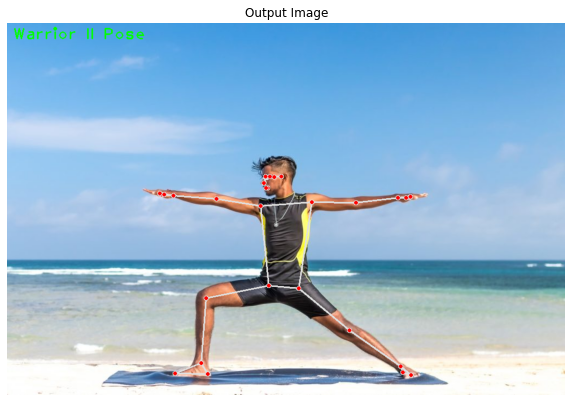

In [73]:
# Read a sample image and perform pose classification on it.
image = cv2.imread('media/warriorIIpose.jpg')
output_image, landmarks = detectPose(image, pose, display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)


after 180

Left Elbow Angle: 177.57452557987608
Right Elbow Angle: 177.03637934259814
Left Shoulder Angle: 103.92314423789936
Right Shoulder Angle: 106.84153990610636
Left Knee Angle: 177.98552924538816
Right Knee Angle: 113.71320942476537
Left Hip Angle: 132.8195652109771
Right Hip Angle: 106.97670588369695
Left shoulder cross: 172.71242190658444
Right shoulder cross: 168.44374572464173


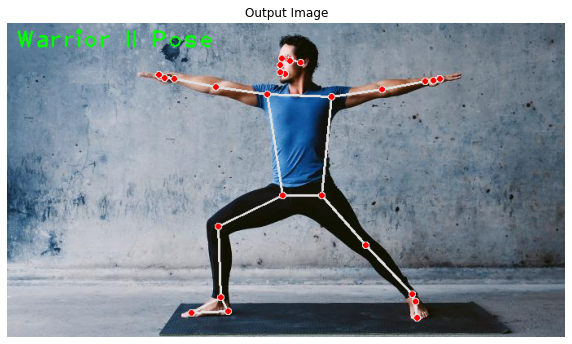

In [74]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/warriorIIpose1.jpg')
output_image, landmarks = detectPose(image, pose, display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

## **<font style="color:rgb(134,19,348)">Tree Pose</font>**

Tree Pose (also known as Vrikshasana) is another yoga pose for which the person has to keep one leg straight and bend the other leg at a required angle. The pose can be classified easily using the following combination of body part angles:

* Around 180° angle at one knee
* Around 35° (if right knee) or 335° (if left knee) angle at the other knee

Now to understand it better, you should go back to the pose classification function above to overview the classification code of this yoga pose.

We will perform pose classification on a few images of people in the tree yoga pose and display the results using the same function we had created above.

I0000 00:00:1712853924.556592  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853924.586787  282115 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 166.62955591098304
Right Elbow Angle: 166.6208945661511
Left Shoulder Angle: 167.55379066637195
Right Shoulder Angle: 178.23231611314165
Left Knee Angle: 177.52957802774748
Right Knee Angle: 27.080595568908084
Left Hip Angle: 179.49594456268193
Right Hip Angle: 118.14192652910234
Left shoulder cross: 78.1146629735266
Right shoulder cross: 82.37992750827033


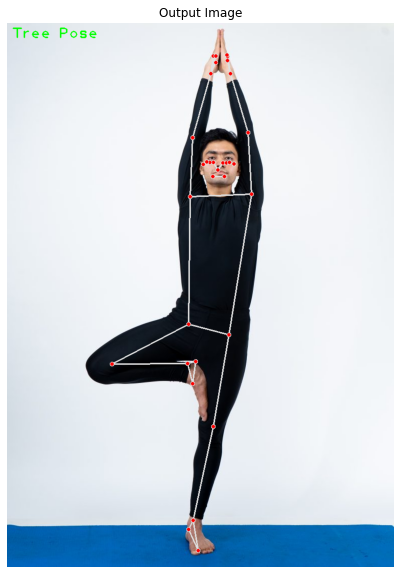

In [75]:
# Read a sample image and perform pose classification on it.
image = cv2.imread('media/treepose.jpg')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)


after 180

Left Elbow Angle: 176.81023477021054
Right Elbow Angle: 151.7940128646936
Left Shoulder Angle: 48.72415651273476
Right Shoulder Angle: 150.64377730429976
Left Knee Angle: 30.60640703150949
Right Knee Angle: 169.86623333903168
Left Hip Angle: 97.13541391334861
Right Hip Angle: 158.5166404792576
Left shoulder cross: 86.253354516625
Right shoulder cross: 167.09244204594486


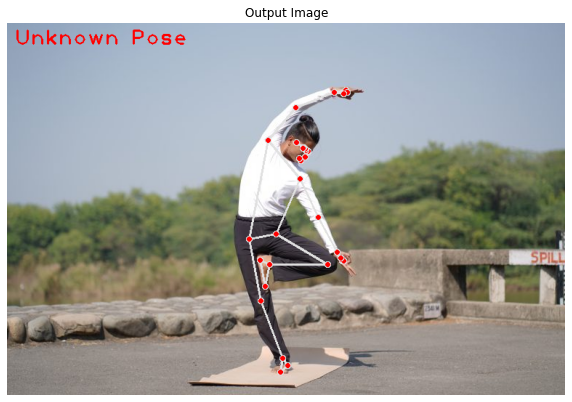

In [76]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/treepose2.jpg')

output_image, landmarks = detectPose(image, pose, display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)




## **<font style="color:rgb(134,19,348)"> Bridge Pose</font>**


I0000 00:00:1712853925.575505  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853925.620239  282147 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 170.2567920676971
Right Elbow Angle: 173.8951163505575
Left Shoulder Angle: 36.054241366350425
Right Shoulder Angle: 25.44231279220412
Left Knee Angle: 79.72021488463116
Right Knee Angle: 79.43385618244955
Left Hip Angle: 177.81396065550513
Right Hip Angle: 176.73143341613527
Left shoulder cross: 98.73424364407549
Right shoulder cross: 82.5543653002224


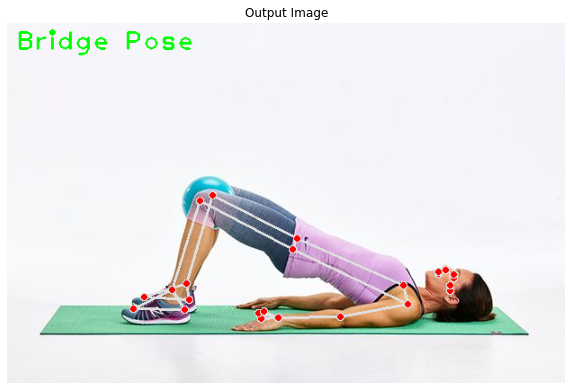

In [77]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/knee_squeeze.jpg')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

I0000 00:00:1712853926.148071  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853926.189303  282156 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 176.6986476731019
Right Elbow Angle: 175.00279046500557
Left Shoulder Angle: 27.41648819746905
Right Shoulder Angle: 34.2513048790497
Left Knee Angle: 75.9386356201822
Right Knee Angle: 70.68813813547257
Left Hip Angle: 173.0714611253002
Right Hip Angle: 177.90969994155273
Left shoulder cross: 83.3185939597774
Right shoulder cross: 99.89153272254464


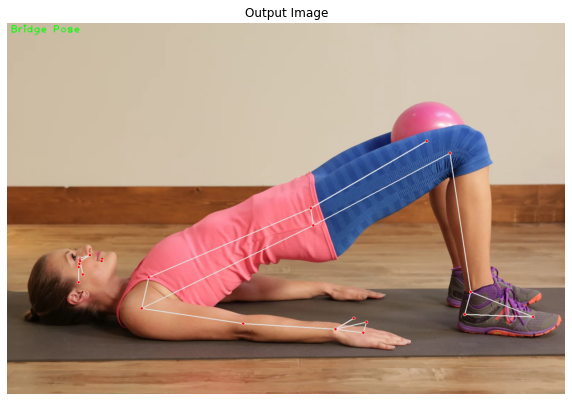

In [78]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/knee_squeeze2.webp')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)


## **<font style="color:rgb(134,19,348)">Lunges</font>**


I0000 00:00:1712853927.020129  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853927.061991  282166 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 42.95459151111278
Right Elbow Angle: 44.08503462251043
Left Shoulder Angle: 18.434948822922006
Right Shoulder Angle: 27.53962928027704
Left Knee Angle: 89.21797835081827
Right Knee Angle: 110.28898345197479
Left Hip Angle: 96.23448009554123
Right Hip Angle: 163.26320345507833
Left shoulder cross: 52.97608181248365
Right shoulder cross: 117.76256333358964


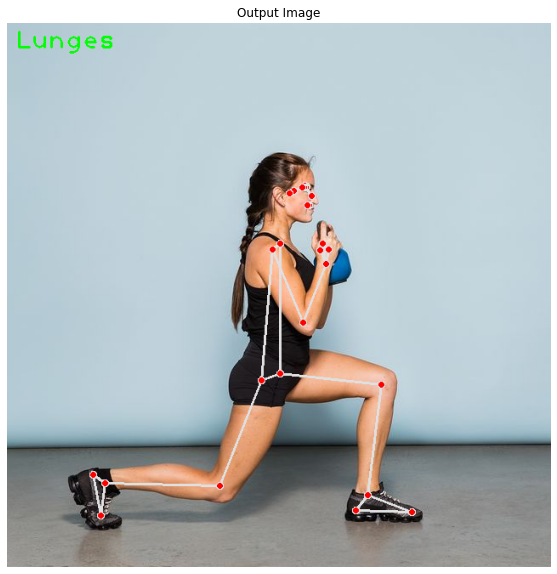

In [79]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/Lunges.jpg')

output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)




## **<font style="color:rgb(134,19,348)">Crunches</font>**


I0000 00:00:1712854192.021805  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712854192.042587  286821 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 95.91852290475353
Right Elbow Angle: 131.9454182600934
Left Shoulder Angle: 109.44643981160635
Right Shoulder Angle: 175.3109706874711
Left Knee Angle: 73.58271415624
Right Knee Angle: 69.88407842699672
Left Hip Angle: 123.66234450576341
Right Hip Angle: 122.90613894560151
Left shoulder cross: 91.2097604118685
Right shoulder cross: 82.6357542291446


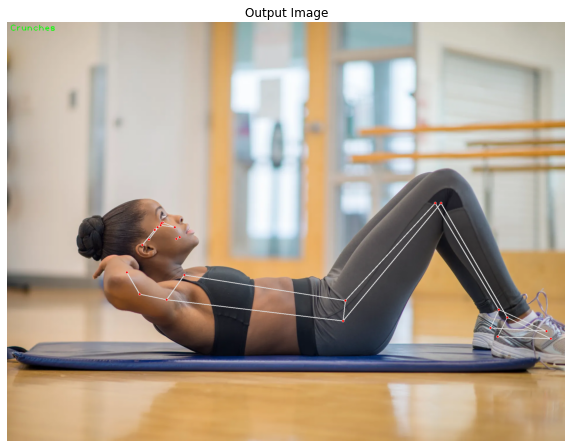

In [98]:


# Read another sample image and perform pose classification on it.
image = cv2.imread('media/crunch.webp')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

I0000 00:00:1712854305.564634  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712854305.611552  288880 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 135.0
Right Elbow Angle: 79.62188531092454
Left Shoulder Angle: 115.51654187080135
Right Shoulder Angle: 94.46920460867551
Left Knee Angle: 63.66978097009056
Right Knee Angle: 82.30088738799171
Left Hip Angle: 115.6148629567742
Right Hip Angle: 126.1482342397656
Left shoulder cross: 96.94279503842716
Right shoulder cross: 84.57605535900807


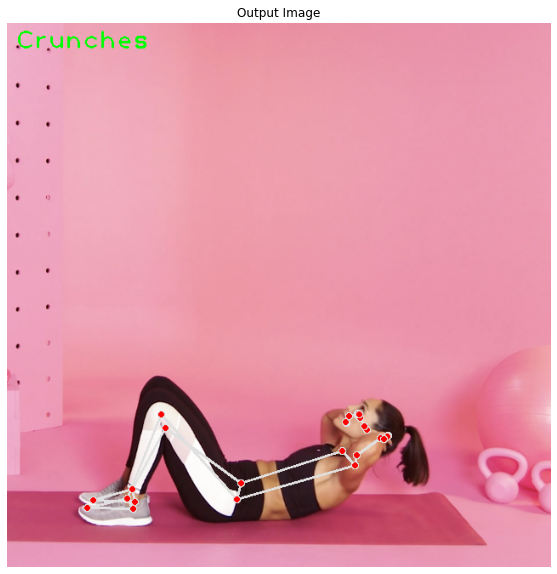

In [102]:
image = cv2.imread('media/crunches2.png')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)


## **<font style="color:rgb(134,19,348)">V Sit</font>**


I0000 00:00:1712853929.782367  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853929.816433  282244 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 164.83412698724717
Right Elbow Angle: 164.2628568103943
Left Shoulder Angle: 56.20517513763654
Right Shoulder Angle: 55.37431973499969
Left Knee Angle: 168.45626984575534
Right Knee Angle: 156.52572575322384
Left Hip Angle: 80.07755997665046
Right Hip Angle: 73.96108859034
Left shoulder cross: 25.14673842987996
Right shoulder cross: 153.8925731132717


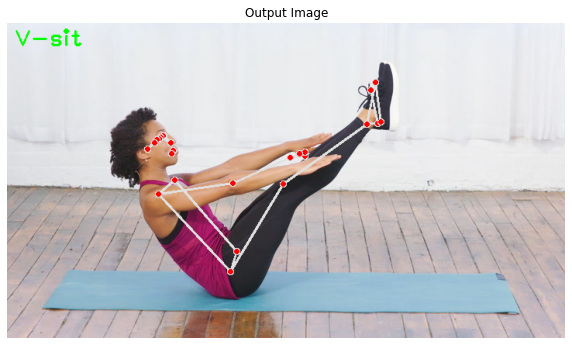

In [82]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/v-sit.jpg')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

I0000 00:00:1712853930.218054  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853930.236984  282254 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 157.56700907787462
Right Elbow Angle: 155.4811823703741
Left Shoulder Angle: 62.37818732518764
Right Shoulder Angle: 61.77837170091124
Left Knee Angle: 174.4170323511733
Right Knee Angle: 177.38517855930903
Left Hip Angle: 93.5764425494325
Right Hip Angle: 94.61874666720195
Left shoulder cross: 161.0205048356003
Right shoulder cross: 18.46921662954963


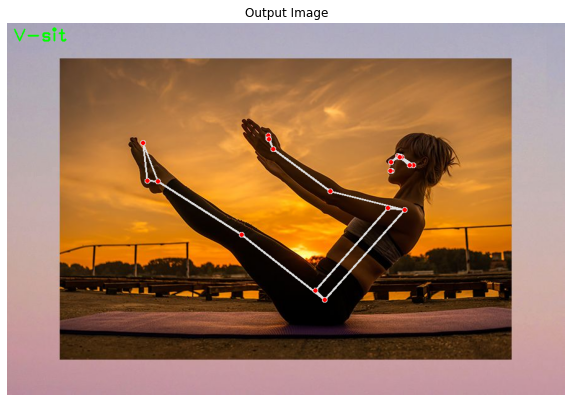

In [83]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/v-sit2.jpg')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

## **<font style="color:rgb(134,19,348)"> Plow </font>**

I0000 00:00:1712853930.779938  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853930.805072  282263 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 176.92277028320564
Right Elbow Angle: 179.33258060272755
Left Shoulder Angle: 81.36102449563884
Right Shoulder Angle: 83.14232202544181
Left Knee Angle: 179.47978676281554
Right Knee Angle: 178.056347389745
Left Hip Angle: 53.46079419274087
Right Hip Angle: 54.553374283043134
Left shoulder cross: 106.79495699168139
Right shoulder cross: 74.51597806302408


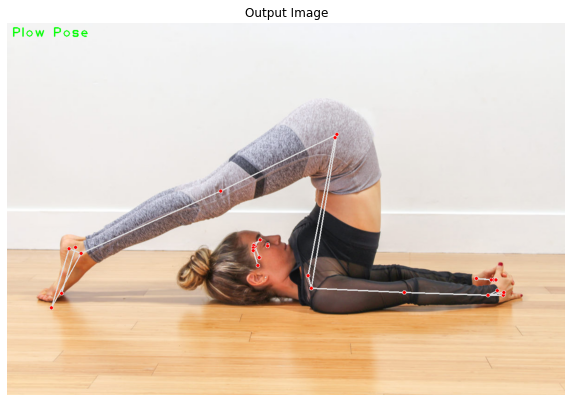

In [84]:

# Read another sample image and perform pose classification on it.
image = cv2.imread('media/plow.jpg')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

## **<font style="color:rgb(134,19,348)">Downward Facing Dog</font>**

I0000 00:00:1712853931.341520  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853931.367243  282280 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 170.32948183507526
Right Elbow Angle: 171.22615193166865
Left Shoulder Angle: 170.24557301610724
Right Shoulder Angle: 173.26039274122883
Left Knee Angle: 167.33274457930065
Right Knee Angle: 164.5778386812613
Left Hip Angle: 75.67276656713484
Right Hip Angle: 69.53081036751783
Left shoulder cross: 94.15337137907841
Right shoulder cross: 84.66260001155729


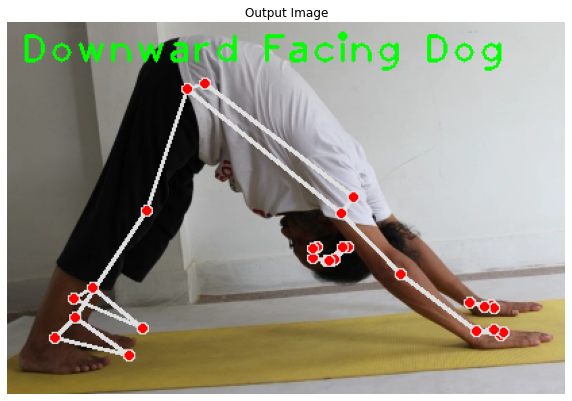

In [85]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/downdog1.webp')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

I0000 00:00:1712853931.779180  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853931.803166  282306 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 167.03178679124352
Right Elbow Angle: 172.22086280908565
Left Shoulder Angle: 176.87767845131367
Right Shoulder Angle: 169.32738362305318
Left Knee Angle: 179.72048861835003
Right Knee Angle: 175.70349235697674
Left Hip Angle: 88.73276370480835
Right Hip Angle: 86.95895718305331
Left shoulder cross: 31.651272886712604
Right shoulder cross: 143.95247333415418


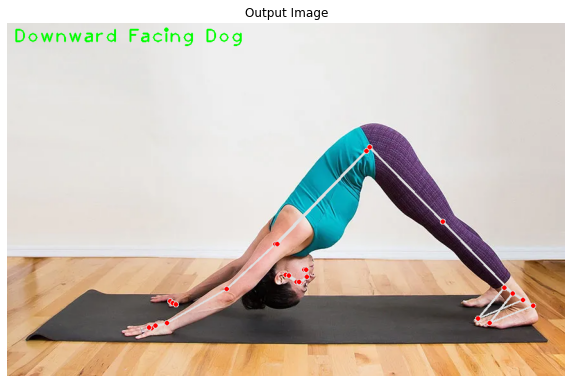

In [86]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/downdog2.webp')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

## **<font style="color:rgb(134,19,348)">Triangle Pose</font>**

I0000 00:00:1712853932.252758  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853932.276715  282315 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 172.09283729704154
Right Elbow Angle: 173.29016319224306
Left Shoulder Angle: 101.37031038070397
Right Shoulder Angle: 99.11507931093985
Left Knee Angle: 173.03247030425547
Right Knee Angle: 171.62159933158847
Left Hip Angle: 138.6965492354108
Right Hip Angle: 41.66375650792526
Left shoulder cross: 169.2166256174318
Right shoulder cross: 177.86049236376883


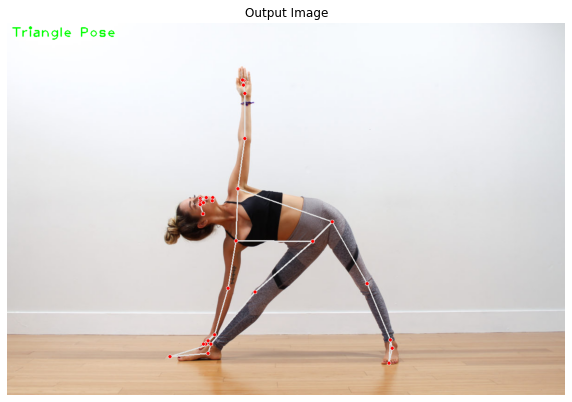

In [87]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/triangle.jpg')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

I0000 00:00:1712853935.817104  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853935.840294  282377 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 175.961958265466
Right Elbow Angle: 179.73765852053006
Left Shoulder Angle: 129.39277175019478
Right Shoulder Angle: 98.05170197500544
Left Knee Angle: 173.89815007553273
Right Knee Angle: 175.67144627942122
Left Hip Angle: 78.78388378911734
Right Hip Angle: 135.42291834186523
Left shoulder cross: 177.7879863937295
Right shoulder cross: 151.4994597447675


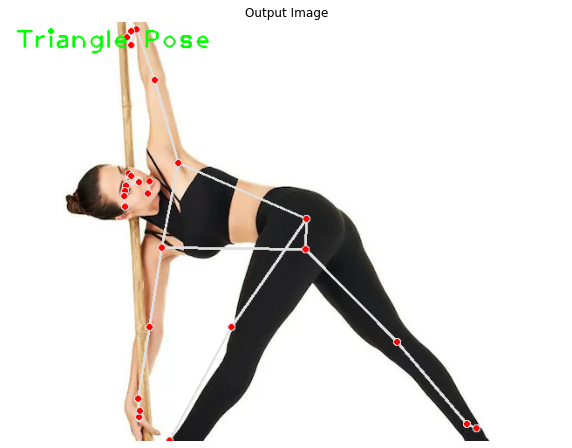

In [88]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/triangle2.webp')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

## **<font style="color:rgb(134,19,348)">Camel</font>**

I0000 00:00:1712853936.238719  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853936.265902  282386 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 178.94179065403748
Right Elbow Angle: 175.46187528487096
Left Shoulder Angle: 63.56681459588032
Right Shoulder Angle: 60.031245738769975
Left Knee Angle: 100.57419620891312
Right Knee Angle: 93.12024739868548
Left Hip Angle: 109.54713676807859
Right Hip Angle: 118.01081780959481
Left shoulder cross: 93.45331625053109
Right shoulder cross: 85.60129464500446


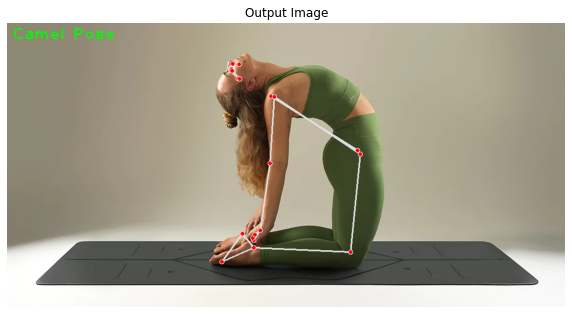

In [89]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/camel.webp')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

I0000 00:00:1712853936.698097  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853936.718938  282395 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 173.30326176535698
Right Elbow Angle: 173.08748440882673
Left Shoulder Angle: 45.15408957788895
Right Shoulder Angle: 61.75721098336995
Left Knee Angle: 108.13010157053517
Right Knee Angle: 80.23705790063968
Left Hip Angle: 107.83787077212548
Right Hip Angle: 120.30290004035317
Left shoulder cross: 170.53131842470836
Right shoulder cross: 22.532078485430418


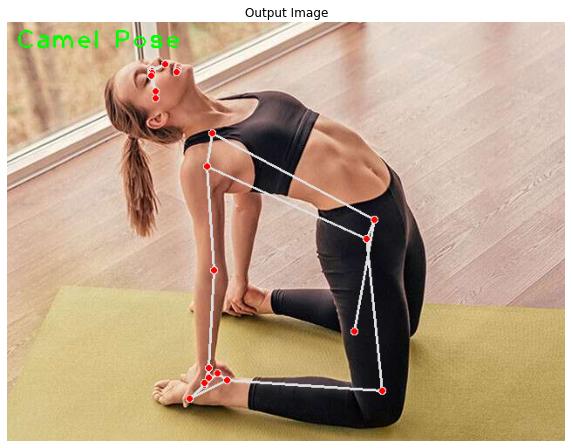

In [90]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/camel2.png')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

## **<font style="color:rgb(134,19,348)">Squat</font>**

I0000 00:00:1712853937.239793  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853937.262211  282405 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 171.75367918553147
Right Elbow Angle: 175.43194800657247
Left Shoulder Angle: 109.36976203490136
Right Shoulder Angle: 110.72915378207688
Left Knee Angle: 75.52199176416383
Right Knee Angle: 55.360480539764076
Left Hip Angle: 76.63924392259315
Right Hip Angle: 62.05110382009099
Left shoulder cross: 171.72443764224607
Right shoulder cross: 6.318873709123636


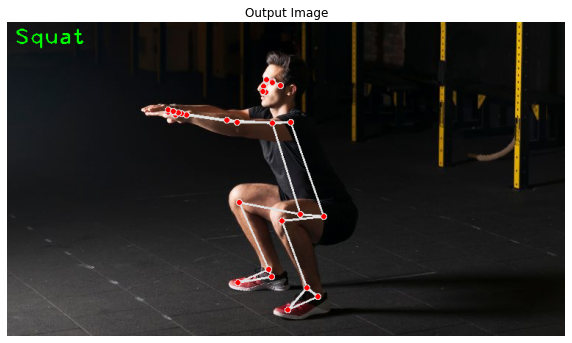

In [91]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/squat.jpg')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

I0000 00:00:1712853937.991715  266109 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1712853938.015148  282437 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 470.239.06), renderer: NVIDIA GeForce MX450/PCIe/SSE2



after 180

Left Elbow Angle: 67.79179650273835
Right Elbow Angle: 8.211988795046977
Left Shoulder Angle: 39.43422119732088
Right Shoulder Angle: 66.28467094932788
Left Knee Angle: 94.83300273756781
Right Knee Angle: 74.67042902887168
Left Hip Angle: 99.56512632836007
Right Hip Angle: 67.19952720306082
Left shoulder cross: 151.80969577368302
Right shoulder cross: 10.994556625630821


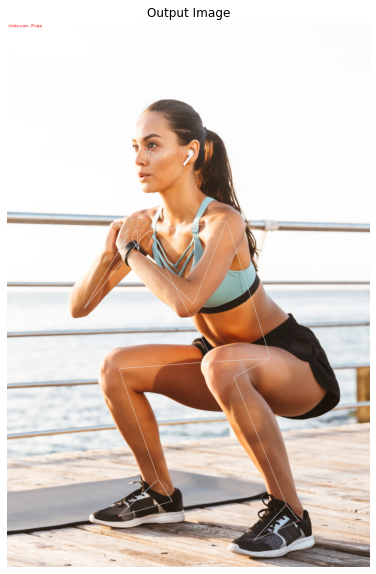

In [92]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/squat2.webp')
output_image, landmarks = detectPose(image, mp_pose.Pose(static_image_mode=True,
                                         min_detection_confidence=0.5, model_complexity=0), display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

## **<font style="color:rgb(134,19,348)">T Pose</font>**

T Pose (also known as a bind pose or reference pose) is the last pose we are dealing with in this lesson. To make this pose, one has to stand up like a tree with both hands wide open as branches. The following body part angles are required to make this one:

* Around 180° at both elbows
* Around 90° angle at both shoulders
* Around 180° angle at both knees

You can now go back to go through the classification code of this T pose in the pose classification function created above.

Now, let's test the pose classification function on a few images of the T pose.


after 180

Left Elbow Angle: 164.80121931173838
Right Elbow Angle: 167.8015596811449
Left Shoulder Angle: 91.47519916284851
Right Shoulder Angle: 94.227147870422
Left Knee Angle: 177.3974377975002
Right Knee Angle: 179.11628221438065
Left Hip Angle: 173.97604351762092
Right Hip Angle: 173.54628718650574
Left shoulder cross: 179.93385498830443
Right shoulder cross: 176.6343600715069


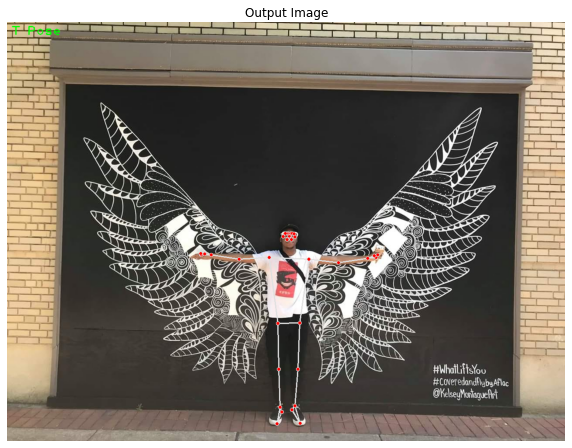

In [93]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/Tpose.jpg')

output_image, landmarks = detectPose(image, pose, display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)


after 180

Left Elbow Angle: 174.5829778861434
Right Elbow Angle: 177.8397295418475
Left Shoulder Angle: 98.767581244553
Right Shoulder Angle: 100.13226733452518
Left Knee Angle: 174.6621036992689
Right Knee Angle: 178.50906413971134
Left Hip Angle: 170.29322780971145
Right Hip Angle: 169.952368790033
Left shoulder cross: 177.03621022390178
Right shoulder cross: 176.85174130692087


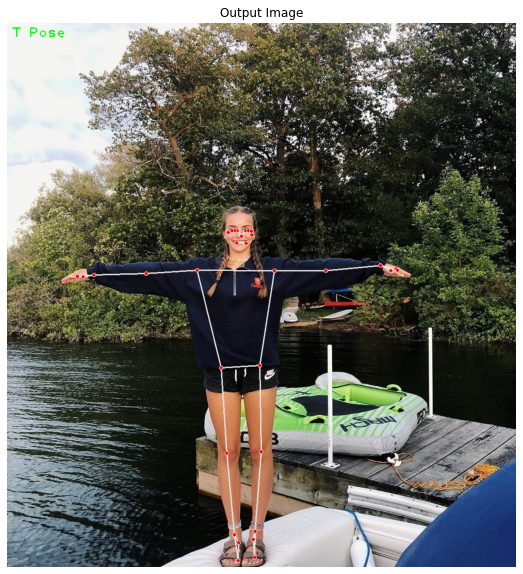

In [94]:
# Read another sample image and perform pose classification on it.

image = cv2.imread('media/Tpose1.jpg')

output_image, landmarks = detectPose(image, pose, display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

So the function is working pretty well on all the known poses on images lets try it on an unknown pose called cobra pose (also known as Bhujangasana).


after 180

Left Elbow Angle: 135.70419298932165
Right Elbow Angle: 134.21073271574178
Left Shoulder Angle: 32.4413872319409
Right Shoulder Angle: 31.485324095861472
Left Knee Angle: 175.0734937784426
Right Knee Angle: 175.29490302273376
Left Hip Angle: 120.5457884186226
Right Hip Angle: 120.00663684421386
Left shoulder cross: 126.121892431732
Right shoulder cross: 52.470134732284635


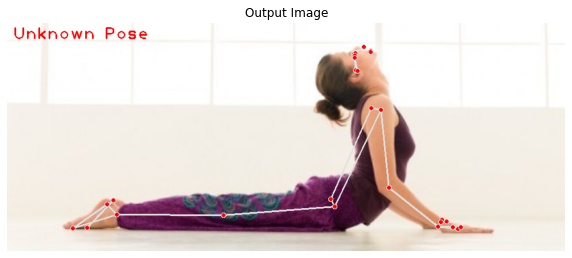

In [95]:
# Read another sample image and perform pose classification on it.
image = cv2.imread('media/cobrapose1.jpg')
output_image, landmarks = detectPose(image, pose, display=False)
if landmarks:
    classifyPose(landmarks, output_image, display=True)

Now if you want you can extend the pose classification function to make it capable of identifying more yoga poses like the one in the image above. The following combination of body part angles can help classify this one:

* Around 180° angle at both knees
* Around 105° (if the person is facing right side) or 240° (if the person is facing left side) angle at both hips

### **<font style="color:rgb(134,19,348)">Pose Classification On Real-Time Webcam Feed</font>**

Now we will test the function created above to perform the pose classification on a real-time webcam feed. 

In [71]:
# # Setup Pose function for video.
# pose_video = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, model_complexity=1)

# # Initialize the VideoCapture object to read from the webcam.
# camera_video = cv2.VideoCapture(0)
# camera_video.set(3,1280)
# camera_video.set(4,960)

# # Initialize a resizable window.
# cv2.namedWindow('Pose Classification', cv2.WINDOW_NORMAL)

# # Iterate until the webcam is accessed successfully.
# while camera_video.isOpened():
    
#     # Read a frame.
#     ok, frame = camera_video.read()
    
#     # Check if frame is not read properly.
#     if not ok:
        
#         # Continue to the next iteration to read the next frame and ignore the empty camera frame.
#         continue
    
#     # Flip the frame horizontally for natural (selfie-view) visualization.
#     frame = cv2.flip(frame, 1)
    
#     # Get the width and height of the frame
#     frame_height, frame_width, _ =  frame.shape
    
#     # Resize the frame while keeping the aspect ratio.
#     frame = cv2.resize(frame, (int(frame_width * (640 / frame_height)), 640))
    
#     # Perform Pose landmark detection.
#     frame, landmarks = detectPose(frame, pose_video, display=False)
    
#     # Check if the landmarks are detected.
#     if landmarks:
        
#         # Perform the Pose Classification.
#         frame, _ = classifyPose(landmarks, frame, display=False)
    
#     # Display the frame.
#     cv2.imshow('Pose Classification', frame)
    
#     # Wait until a key is pressed.
#     # Retreive the ASCII code of the key pressed
#     k = cv2.waitKey(1) & 0xFF
    
#     # Check if 'ESC' is pressed.
#     if(k == 27):
        
#         # Break the loop.
#         break

# # Release the VideoCapture object and close the windows.
# camera_video.release()
# cv2.destroyAllWindows()

As expected, the results were amazing, if you were having difficulty in making the poses you can expand the range of angles used in the classification function, but that may open up the possibility of false positives.